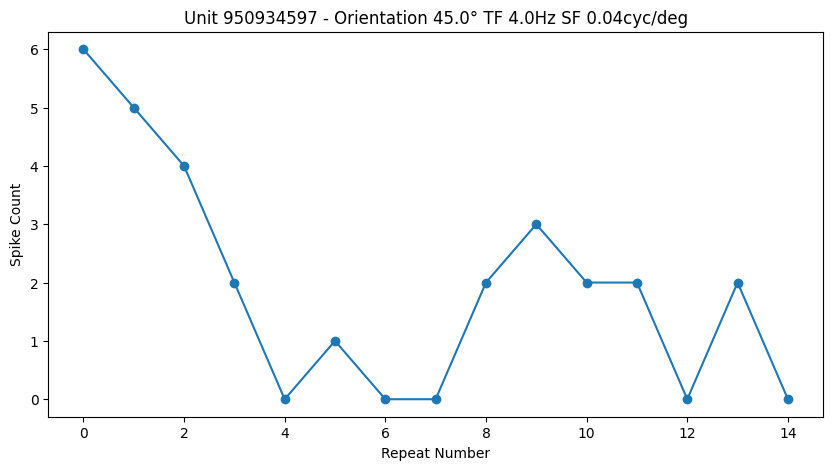

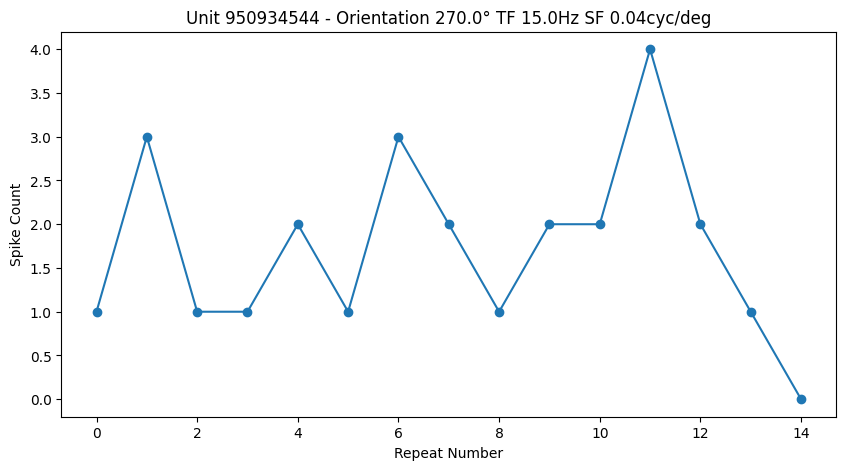

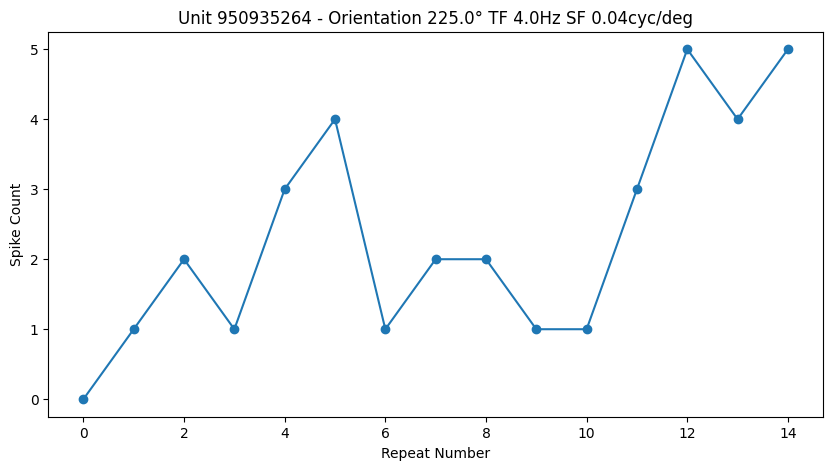

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.stats import wilcoxon

# Load your processed CSV
df = pd.read_csv('processed_data_drifting_gratings.csv')

# Pick some example units
example_units = random.sample(list(df['unit_id'].unique()), 3)

for unit_id in example_units:
    plt.figure(figsize=(10, 5))
    
    unit_data = df[df['unit_id'] == unit_id]
    
    # Instead of picking the most frequent condition, pick a random one
    unique_conditions = unit_data[['orientation', 'temporal_frequency', 'spatial_frequency']].drop_duplicates()
    condition = unique_conditions.sample(1).iloc[0]
    
    condition_data = unit_data[
        (unit_data['orientation'] == condition['orientation']) &
        (unit_data['temporal_frequency'] == condition['temporal_frequency']) &
        (unit_data['spatial_frequency'] == condition['spatial_frequency'])
    ]
    
    plt.plot(condition_data['repeat_number'], condition_data['spike_count'], 'o-')
    plt.title(f"Unit {unit_id} - Orientation {condition['orientation']}° TF {condition['temporal_frequency']}Hz SF {condition['spatial_frequency']}cyc/deg")
    plt.xlabel('Repeat Number')
    plt.ylabel('Spike Count')
    plt.show()


In [24]:
from scipy.stats import linregress

# Prepare list to collect results
adaptation_slopes = []

# Loop over each unique neuron
for unit_id in df['unit_id'].unique():
    unit_data = df[df['unit_id'] == unit_id]
    
    # Loop over each unique stimulus condition for that neuron
    conditions = unit_data[['orientation', 'temporal_frequency', 'spatial_frequency']].drop_duplicates()
    
    for _, condition in conditions.iterrows():
        condition_data = unit_data[
            (unit_data['orientation'] == condition['orientation']) &
            (unit_data['temporal_frequency'] == condition['temporal_frequency']) &
            (unit_data['spatial_frequency'] == condition['spatial_frequency'])
        ]
        
        # Make sure there are enough repeats (otherwise regression is unreliable)
        if len(condition_data) >= 5:
            x = condition_data['repeat_number']
            y = condition_data['spike_count']
            
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            
            adaptation_slopes.append({
                'unit_id': unit_id,
                'orientation': condition['orientation'],
                'temporal_frequency': condition['temporal_frequency'],
                'spatial_frequency': condition['spatial_frequency'],
                'slope': slope,
                'r_value': r_value,
                'p_value': p_value
            })


df_slopes = pd.DataFrame(adaptation_slopes)
df_slopes.to_csv('adaptation_slopes.csv', index=False)

print(f"Computed adaptation slopes for {len(df_slopes)} neuron-condition pairs.")


Computed adaptation slopes for 840 neuron-condition pairs.


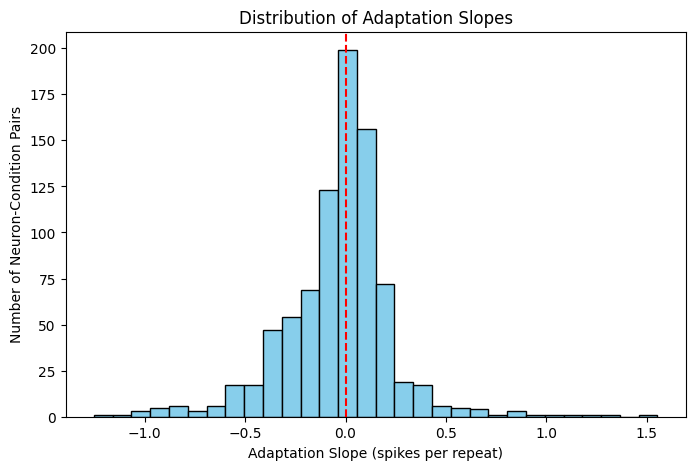

Percentage adapting: 50.0%


In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df_slopes['slope'], bins=30, color='skyblue', edgecolor='k')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Adaptation Slope (spikes per repeat)')
plt.ylabel('Number of Neuron-Condition Pairs')
plt.title('Distribution of Adaptation Slopes')
plt.show()

num_adapting = (df_slopes['slope'] < 0).sum()
num_total = len(df_slopes)
print(f"Percentage adapting: {100 * num_adapting / num_total:.1f}%")


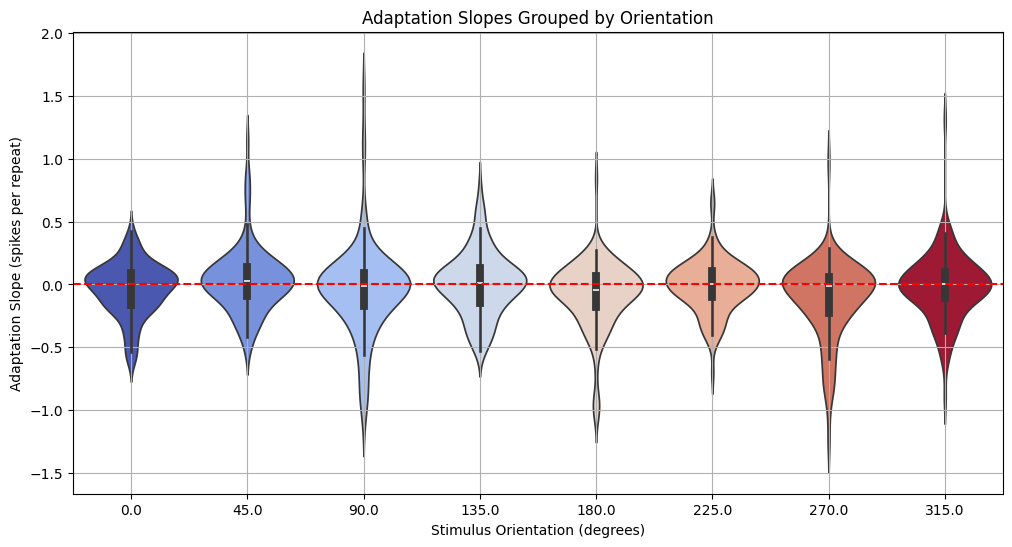

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load your previously computed slopes
df_slopes = pd.read_csv('adaptation_slopes.csv')

# (OPTIONAL) Round orientations a bit if needed
df_slopes['orientation'] = df_slopes['orientation'].round(1)

# Plot violinplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_slopes, x='orientation', y='slope', inner='box', hue='orientation', palette='coolwarm', legend=False)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Stimulus Orientation (degrees)')
plt.ylabel('Adaptation Slope (spikes per repeat)')
plt.title('Adaptation Slopes Grouped by Orientation')
plt.grid(True)
plt.show()


------ Adaptation Significance Test ------
Total neuron-condition pairs: 840
Mean slope: -0.0347
Median slope: -0.0000
Proportion adapting (slope < 0): 50.0%
Wilcoxon statistic: 146026.0000
P-value (H0: median slope >= 0): 1.8698e-03
------------------------------------------


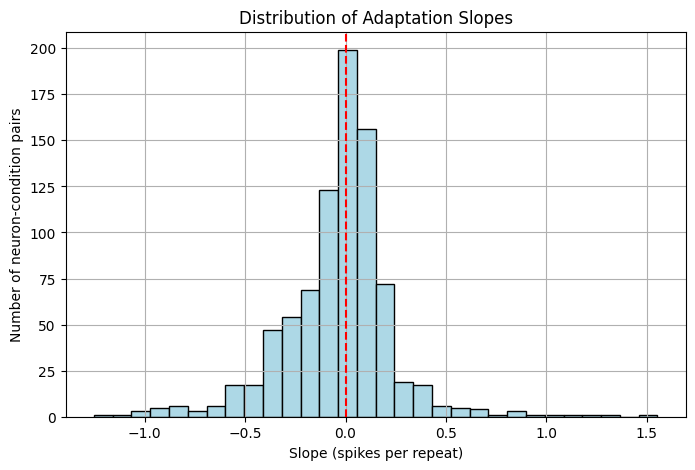

In [30]:
# Filter out any NaNs just in case
df_slopes = df_slopes.dropna(subset=["slope"])

# Wilcoxon signed-rank test: H0 = slopes >= 0, H1 = slopes < 0 (adaptation)
stat, p_value = wilcoxon(df_slopes["slope"], alternative='less')

# Proportion of adapting units (negative slope)
proportion_adapting = (df_slopes["slope"] < 0).mean() * 100

# Display results
print("------ Adaptation Significance Test ------")
print(f"Total neuron-condition pairs: {len(df_slopes)}")
print(f"Mean slope: {df_slopes['slope'].mean():.4f}")
print(f"Median slope: {df_slopes['slope'].median():.4f}")
print(f"Proportion adapting (slope < 0): {proportion_adapting:.1f}%")
print(f"Wilcoxon statistic: {stat:.4f}")
print(f"P-value (H0: median slope >= 0): {p_value:.4e}")
print("------------------------------------------")

# Optional: plot distribution
plt.figure(figsize=(8, 5))
plt.hist(df_slopes['slope'], bins=30, color='lightblue', edgecolor='k')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Adaptation Slopes")
plt.xlabel("Slope (spikes per repeat)")
plt.ylabel("Number of neuron-condition pairs")
plt.grid(True)
plt.show()


## 🧠 Interpretation:
- Mean slope: −0.0347 → small but negative average trend: many units reduce firing over repetitions.
- Median slope: ~0.0 → suggests a symmetric distribution; but not centered exactly at zero.
- Proportion adapting: 50.0% → half the conditions show negative adaptation slope.
- P-value: 0.00187 → statistically significant evidence (p < 0.05) that slopes are less than zero, i.e., adaptation exists across the population.

This shows that V1 neurons do, on average, adapt to repeated stimuli, even if the effect is modest.

In [33]:
# Round orientation for grouping consistency
df_slopes['orientation'] = df_slopes['orientation'].round(1)

# Group by orientation and compute descriptive stats
grouped = df_slopes.groupby('orientation')['slope']
group_means = grouped.mean()
group_medians = grouped.median()

print("Mean slope per orientation:")
print(group_means)

print("\nMedian slope per orientation:")
print(group_medians)


Mean slope per orientation:
orientation
0.0     -0.034922
45.0     0.034082
90.0    -0.050374
135.0    0.007517
180.0   -0.083707
225.0   -0.011531
270.0   -0.117959
315.0   -0.021088
Name: slope, dtype: float64

Median slope per orientation:
orientation
0.0      0.000000e+00
45.0     2.500000e-02
90.0    -1.071429e-02
135.0    1.428571e-02
180.0   -4.285714e-02
225.0    0.000000e+00
270.0   -1.428571e-02
315.0   -8.723181e-18
Name: slope, dtype: float64


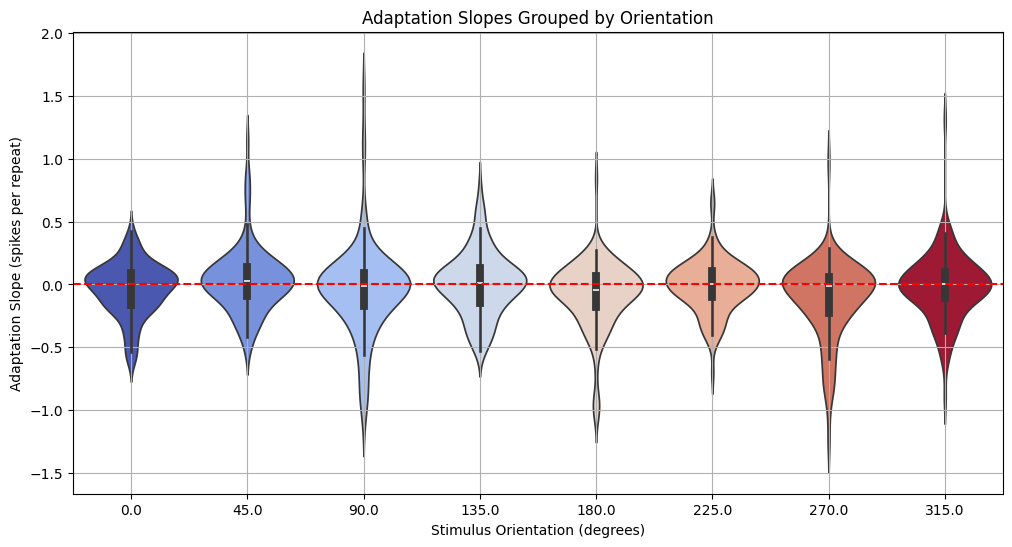

In [71]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_slopes, x='orientation', y='slope', inner='box',hue='orientation', palette='coolwarm', legend=False)
plt.axhline(0, color='red', linestyle='--')
plt.title('Adaptation Slopes Grouped by Orientation')
plt.xlabel('Stimulus Orientation (degrees)')
plt.ylabel('Adaptation Slope (spikes per repeat)')
plt.grid(True)
plt.show()


### Stronger adaptation (more negative mean slope):
- 270°: −0.118
- 180°: −0.084
- 90°: −0.050
### Weak or reversed adaptation:
- 45°: +0.034
- 135°: +0.0075
  
So some orientations even show a facilitatory trend, while others clearly adapt more strongly.

In [38]:
from scipy.stats import kruskal

# Build list of slope arrays grouped by orientation
slope_groups = [group['slope'].values for _, group in df_slopes.groupby('orientation')]

# Kruskal-Wallis test: nonparametric ANOVA
H, p = kruskal(*slope_groups)

print("Kruskal-Wallis test across orientations:")
print(f"H-statistic: {H:.4f}")
print(f"P-value: {p:.4e}")


Kruskal-Wallis test across orientations:
H-statistic: 15.7950
P-value: 2.7057e-02


In [40]:
# Mean adaptation slope per temporal frequency
print("Mean slope by temporal frequency:")
print(df_slopes.groupby('temporal_frequency')['slope'].mean())

# Mean adaptation slope per spatial frequency
print("\nMean slope by spatial frequency:")
print(df_slopes.groupby('spatial_frequency')['slope'].mean())


Mean slope by temporal frequency:
temporal_frequency
1.0    -0.003926
2.0    -0.051743
4.0    -0.031314
8.0    -0.066901
15.0   -0.019855
Name: slope, dtype: float64

Mean slope by spatial frequency:
spatial_frequency
0.04   -0.034748
Name: slope, dtype: float64


In [46]:
from scipy.stats import kruskal

# Filter out empty spatial frequency groups
sf_groups = [group['slope'].values for _, group in df_slopes.groupby('spatial_frequency')]
sf_groups = [g for g in sf_groups if len(g) > 0]  # remove empty groups

tf_groups = [group['slope'].values for _, group in df_slopes.groupby('temporal_frequency')]
tf_groups = [g for g in tf_groups if len(g) > 0]

# Only run if you have at least 2 groups
if len(tf_groups) >= 2:
    H_tf, p_tf = kruskal(*tf_groups)
else:
    H_tf, p_tf = None, None
    print("Not enough temporal frequency groups to run test.")

if len(sf_groups) >= 2:
    H_sf, p_sf = kruskal(*sf_groups)
else:
    H_sf, p_sf = None, None
    print("Not enough spatial frequency groups to run test.")

# Display results
print("Kruskal–Wallis Test Results:")
print(f"Temporal Frequency: H = {H_tf}, p = {p_tf}")
print(f"Spatial Frequency : H = {H_sf}, p = {p_sf}")


Not enough spatial frequency groups to run test.
Kruskal–Wallis Test Results:
Temporal Frequency: H = 5.1248095138761265, p = 0.2747293228466906
Spatial Frequency : H = None, p = None


## Interpretation:

### 📉 Temporal Frequency:
H = 5.12, p = 0.275 → not statistically significant

No strong evidence that adaptation strength differs across temporal frequencies in your data.

### ❌ Spatial Frequency:
Not enough variety or valid data across spatial frequencies — maybe only one was used or others lacked sufficient trials.

In [53]:
# Step 1: Get preferred orientation for each neuron
unit_preferences = (
    df.groupby(['unit_id', 'orientation'])['spike_count']
    .mean()
    .reset_index()
    .sort_values(['unit_id', 'spike_count'], ascending=[True, False])
    .drop_duplicates(subset='unit_id')
    .rename(columns={'orientation': 'preferred_orientation'})
)

# Merge back into df_slopes
df_pref = pd.merge(df_slopes, unit_preferences[['unit_id', 'preferred_orientation']], on='unit_id')

# Label as preferred or not
df_pref['is_preferred'] = df_pref['orientation'] == df_pref['preferred_orientation']


In [55]:
# Split groups
slopes_pref = df_pref[df_pref['is_preferred']]['slope']
slopes_nonpref = df_pref[~df_pref['is_preferred']]['slope']

# Summary stats
print(f"Mean slope (preferred): {slopes_pref.mean():.4f}")
print(f"Mean slope (non-preferred): {slopes_nonpref.mean():.4f}")


Mean slope (preferred): -0.0533
Mean slope (non-preferred): -0.0321


In [57]:
from scipy.stats import mannwhitneyu

# Mann–Whitney U test (non-parametric)
stat, p = mannwhitneyu(slopes_pref, slopes_nonpref, alternative='less')

print("Mann–Whitney U Test:")
print(f"U statistic = {stat:.2f}")
print(f"p-value = {p:.4e}")


Mann–Whitney U Test:
U statistic = 37811.50
p-value = 3.6939e-01
